# **EDA: Edge-collected-gunshot dataset (CSV)**

**Fuente:** Elaboración propia (Andrés)

Este dataset contiene **2.148 grabaciones** de disparos reales distribuidas en 4 clases (`9mm`, `38cal`, `AR15`, `12gauge`), capturadas durante 2 sesiones de grabación en un campo de tiro. Cada registro incluye metadatos del dispositivo de captura, coordenadas GPS, una marca temporal y la localización exacta de cada disparo dentro del audio. Se está utilizando este dataset para reforzar la clase `gunshot` en el dataset final del modelo.

## **1. Importaciones y configuración**

In [1]:
# Instalar dependencias necesarias
%pip install librosa soundfile kaggle tqdm seaborn scikit-learn

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import zipfile
import librosa
import librosa.display
import ast
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print('Librerías cargadas.')

Librerías cargadas.


In [3]:
# Configuración de estilo
sns.set_theme(style="darkgrid", palette="husl")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

## **2. Carga y estructura del dataset**

In [4]:
df = pd.read_csv("/content/gunshot-audio-all-metadata.csv")

# Limpiar espacios en los nombres de las columnas
df.columns = df.columns.str.strip()

# Convertir timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)

# time_offset_s: outliers extremos --> los valores gigantes son offsets erróneos
# Filtramos outliers obvios (>3 std) para el análisis descriptivo
df['time_offset_clean'] = df['time_offset_s'].copy()
q_high = df['time_offset_s'].quantile(0.99)
q_low = df['time_offset_s'].quantile(0.01)
df.loc[(df['time_offset_s'] > q_high) | (df['time_offset_s'] < q_low), 'time_offset_clean'] = np.nan

In [5]:
print(f"Shape: {df.shape[0]} filas × {df.shape[1]} columnas")

Shape: 2148 filas × 17 columnas


In [6]:
df.head(10)

,filename,uuid,label,recording_session,timestamp,time_offset_s,device_name,device_manufacturer,device_model,microphone,firearm,caliber,latitude,longitude,gunshot_location_in_seconds,num_gunshots,time_offset_clean
0,880b3ce5-9c19-4c12-a813-b223bb4f2897_v1,880b3ce5-9c19-4c12-a813-b223bb4f2897,9mm,1,2021-11-15 16:46:11.907000+00:00,17.614000,Galaxy S21 5G Lemon Brownie,Samsung,SM-G991U1,Samsung Galaxy S21 Internal Mic,Glock 17,9mm,28.342295,-80.781939,[1.72269841],1,NaN
1,fed855d4-d9c4-42c5-a5c5-ddc5edd69e14_v0,fed855d4-d9c4-42c5-a5c5-ddc5edd69e14,9mm,1,2021-11-15 16:47:41.122000+00:00,17.614000,Galaxy S21 5G Lemon Brownie,Samsung,SM-G991U1,Samsung Galaxy S21 Internal Mic,Glock 17,9mm,28.342295,-80.781939,[1.67290249],1,NaN
2,369d77b1-3141-40e2-8fb5-77d57d560472_v0,369d77b1-3141-40e2-8fb5-77d57d560472,9mm,1,2021-11-15 16:50:03.647000+00:00,17.636999,Galaxy S21 5G Lemon Brownie,Samsung,SM-G991U1,Samsung Galaxy S21 Internal Mic,Glock 17,9mm,28.342295,-80.781939,[1.61977324 3.50795918 5.42746032],3,NaN
3,cfe036af-d99f-46a5-8829-32a66b45be70_v1,cfe036af-d99f-46a5-8829-32a66b45be70,9mm,1,2021-11-15 16:51:30.693000+00:00,17.547001,Galaxy S21 5G Lemon Brownie,Samsung,SM-G991U1,Samsung Galaxy S21 Internal Mic,Glock 17,9mm,28.342295,-80.781939,[1.75 1.98768707 2.26022676],3,17.547001
4,b0f71933-ce93-45ae-bf09-6838af56c0ee_v0,b0f71933-ce93-45ae-bf09-6838af56c0ee,9mm,1,2021-11-15 16:52:47.686000+00:00,17.579000,Galaxy S21 5G Lemon Brownie,Samsung,SM-G991U1,Samsung Galaxy S21 Internal Mic,Glock 17,9mm,28.342295,-80.781939,[1.75 2.61845805 3.06664399],3,17.579000
5,f4795b52-6cf1-4d72-bb79-b0764509a1c8_v0,f4795b52-6cf1-4d72-bb79-b0764509a1c8,9mm,1,2021-11-15 16:54:30.196000+00:00,17.615000,Galaxy S21 5G Lemon Brownie,Samsung,SM-G991U1,Samsung Galaxy S21 Internal Mic,Glock 17,9mm,28.342295,-80.781939,[1.50206349 1.75 1.95494331 2.15668934 2...,5,NaN
6,820abb87-01bd-47d3-a2b8-f17cfd0bd6a7_v0,820abb87-01bd-47d3-a2b8-f17cfd0bd6a7,38cal,1,2021-11-15 16:57:52.290000+00:00,17.542000,Galaxy S21 5G Lemon Brownie,Samsung,SM-G991U1,Samsung Galaxy S21 Internal Mic,Smith & Wesson,.38 cal,28.342295,-80.781939,[1.75],1,17.542000
7,0adeaece-8ec1-440b-ae3a-1dc93613f76f_v0,0adeaece-8ec1-440b-ae3a-1dc93613f76f,38cal,1,2021-11-15 16:58:24.340000+00:00,17.559000,Galaxy S21 5G Lemon Brownie,Samsung,SM-G991U1,Samsung Galaxy S21 Internal Mic,Smith & Wesson,.38 cal,28.342295,-80.781939,[1.75],1,17.559000
8,a658fd9a-dabe-465f-9efb-67f0d1c3be84_v1,a658fd9a-dabe-465f-9efb-67f0d1c3be84,38cal,1,2021-11-15 16:58:48.849000+00:00,17.559000,Galaxy S21 5G Lemon Brownie,Samsung,SM-G991U1,Samsung Galaxy S21 Internal Mic,Smith & Wesson,.38 cal,28.342295,-80.781939,[1.61907029],1,17.559000
9,28d97af9-0450-4dc5-a40a-1eb40e387bf2_v0,28d97af9-0450-4dc5-a40a-1eb40e387bf2,38cal,1,2021-11-15 16:59:29.253000+00:00,NaN,Galaxy S21 5G Lemon Brownie,Samsung,SM-G991U1,Samsung Galaxy S21 Internal Mic,Smith & Wesson,.38 cal,28.342295,-80.781939,[1.62088435 3.31027211 5.11040816],3,NaN


In [7]:
df.tail(10)

,filename,uuid,label,recording_session,timestamp,time_offset_s,device_name,device_manufacturer,device_model,microphone,firearm,caliber,latitude,longitude,gunshot_location_in_seconds,num_gunshots,time_offset_clean
2138,889f15aa-9b06-472b-8a87-85434b13dc0f_chan1_v0,889f15aa-9b06-472b-8a87-85434b13dc0f,AR15,2,2021-11-22 14:59:51.580045+00:00,-0.063162,P7,Raspberry Pi,Zero W,ReSpeaker 2-Mics Pi HAT,Ruger 556,.223 mm,28.34195,-80.78151,[1.71306122],1,-0.063162
2139,889f15aa-9b06-472b-8a87-85434b13dc0f_chan1_v1,889f15aa-9b06-472b-8a87-85434b13dc0f,AR15,2,2021-11-22 14:59:51.580045+00:00,-0.063162,P7,Raspberry Pi,Zero W,ReSpeaker 2-Mics Pi HAT,Ruger 556,.223 mm,28.34195,-80.78151,[1.72557823],1,-0.063162
2140,889f15aa-9b06-472b-8a87-85434b13dc0f_chan1_v2,889f15aa-9b06-472b-8a87-85434b13dc0f,AR15,2,2021-11-22 14:59:51.580045+00:00,-0.063162,P7,Raspberry Pi,Zero W,ReSpeaker 2-Mics Pi HAT,Ruger 556,.223 mm,28.34195,-80.78151,[1.75],1,-0.063162
2141,889f15aa-9b06-472b-8a87-85434b13dc0f_mean_v0,889f15aa-9b06-472b-8a87-85434b13dc0f,AR15,2,2021-11-22 14:59:51.580045+00:00,-0.063162,P7,Raspberry Pi,Zero W,ReSpeaker 2-Mics Pi HAT,Ruger 556,.223 mm,28.34195,-80.78151,[1.62346939],1,-0.063162
2142,889f15aa-9b06-472b-8a87-85434b13dc0f_mean_v1,889f15aa-9b06-472b-8a87-85434b13dc0f,AR15,2,2021-11-22 14:59:51.580045+00:00,-0.063162,P7,Raspberry Pi,Zero W,ReSpeaker 2-Mics Pi HAT,Ruger 556,.223 mm,28.34195,-80.78151,[1.70102041],1,-0.063162
2143,889f15aa-9b06-472b-8a87-85434b13dc0f_mean_v2,889f15aa-9b06-472b-8a87-85434b13dc0f,AR15,2,2021-11-22 14:59:51.580045+00:00,-0.063162,P7,Raspberry Pi,Zero W,ReSpeaker 2-Mics Pi HAT,Ruger 556,.223 mm,28.34195,-80.78151,[1.7406576],1,-0.063162
2144,889f15aa-9b06-472b-8a87-85434b13dc0f_mean_v3,889f15aa-9b06-472b-8a87-85434b13dc0f,AR15,2,2021-11-22 14:59:51.580045+00:00,-0.063162,P7,Raspberry Pi,Zero W,ReSpeaker 2-Mics Pi HAT,Ruger 556,.223 mm,28.34195,-80.78151,[1.66732426],1,-0.063162
2145,15d53f4b-0e9d-476e-b321-6ca604f89412_chan0_v0,15d53f4b-0e9d-476e-b321-6ca604f89412,AR15,2,2021-11-22 15:01:50.850118+00:00,-0.063487,P7,Raspberry Pi,Zero W,ReSpeaker 2-Mics Pi HAT,Ruger 556,.223 mm,28.34195,-80.78151,[1.53469388 1.74122449 2.14659864 2.3253288 2...,5,-0.063487
2146,15d53f4b-0e9d-476e-b321-6ca604f89412_chan1_v0,15d53f4b-0e9d-476e-b321-6ca604f89412,AR15,2,2021-11-22 15:01:50.850118+00:00,-0.063487,P7,Raspberry Pi,Zero W,ReSpeaker 2-Mics Pi HAT,Ruger 556,.223 mm,28.34195,-80.78151,[1.75 1.94283447 2.34698413 2.52979592 2...,5,-0.063487
2147,15d53f4b-0e9d-476e-b321-6ca604f89412_mean_v0,15d53f4b-0e9d-476e-b321-6ca604f89412,AR15,2,2021-11-22 15:01:50.850118+00:00,-0.063487,P7,Raspberry Pi,Zero W,ReSpeaker 2-Mics Pi HAT,Ruger 556,.223 mm,28.34195,-80.78151,[1.73544218 1.9731746 2.04947846 2.38258503 2...,6,-0.063487


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2148 entries, 0 to 2147
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype              
---  ------                       --------------  -----              
 0   filename                     2148 non-null   object             
 1   uuid                         2148 non-null   object             
 2   label                        2148 non-null   object             
 3   recording_session            2148 non-null   int64              
 4   timestamp                    2148 non-null   datetime64[ns, UTC]
 5   time_offset_s                2090 non-null   float64            
 6   device_name                  2148 non-null   object             
 7   device_manufacturer          2148 non-null   object             
 8   device_model                 2148 non-null   object             
 9   microphone                   2148 non-null   object             
 10  firearm                      2148 non-null   obj

In [9]:
df.columns

Index(['filename', 'uuid', 'label', 'recording_session', 'timestamp',
       'time_offset_s', 'device_name', 'device_manufacturer', 'device_model',
       'microphone', 'firearm', 'caliber', 'latitude', 'longitude',
       'gunshot_location_in_seconds', 'num_gunshots', 'time_offset_clean'],
      dtype='object')

In [10]:
# Valores nulos
print("Valores nulos")
nulls = df.isnull().sum().rename('nulos')
pct = (nulls / len(df) * 100).rename('%')
display(pd.concat([nulls, pct], axis=1).query("nulos > 0"))

Valores nulos


,nulos,%
time_offset_s,58,2.700186
time_offset_clean,100,4.655493


In [11]:
# Duplicados
print("Valores duplicados")
dupes = df.duplicated(subset='uuid').sum()
print(f"\nFilas duplicadas por UUID: {dupes}")

Valores duplicados

Filas duplicadas por UUID: 1599


In [12]:
print("Valores faltantes del dataframe")
df.isna().sum().sum()

Valores faltantes del dataframe


np.int64(158)

In [13]:
print("Valores faltantes para cada columna")
df.isna().sum()

Valores faltantes para cada columna


,0
filename,0
uuid,0
label,0
recording_session,0
timestamp,0
time_offset_s,58
device_name,0
device_manufacturer,0
device_model,0
microphone,0


In [14]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

,0
time_offset_clean,4.655493
time_offset_s,2.700186
filename,0.000000
recording_session,0.000000
uuid,0.000000
timestamp,0.000000
device_name,0.000000
device_manufacturer,0.000000
label,0.000000
device_model,0.000000


In [15]:
print("Tipos de datos")
df.dtypes

Tipos de datos


,0
filename,object
uuid,object
label,object
recording_session,int64
timestamp,"datetime64[ns, UTC]"
time_offset_s,float64
device_name,object
device_manufacturer,object
device_model,object
microphone,object


In [16]:
print("Posibles variables categóricas")
df.select_dtypes(include=['object']).columns

Posibles variables categóricas


Index(['filename', 'uuid', 'label', 'device_name', 'device_manufacturer',
       'device_model', 'microphone', 'firearm', 'caliber',
       'gunshot_location_in_seconds'],
      dtype='object')

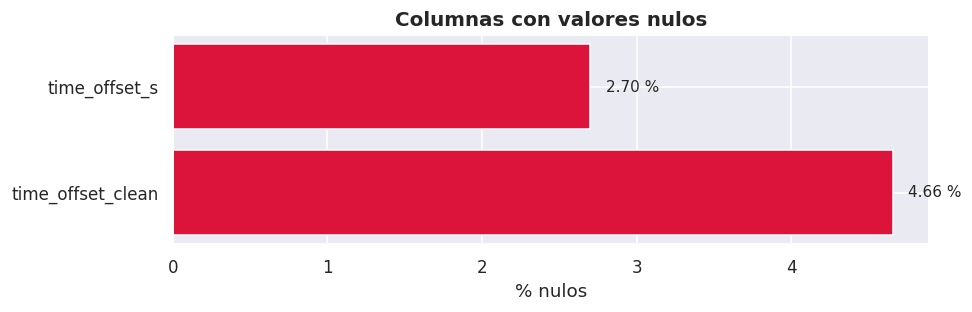

Solo 'time_offset_s' tiene nulos (~2.7 %). Es manejable con imputación o exclusión.


In [17]:
# Visualización de nulos
fig, ax = plt.subplots(figsize=(9, 3))
null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]
bars = ax.barh(null_pct.index, null_pct.values, color='crimson', edgecolor='white')
ax.set_xlabel("% nulos")
ax.set_title("Columnas con valores nulos")
for bar, val in zip(bars, null_pct.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f"{val:.2f} %", va='center', fontsize=10)
plt.tight_layout()
plt.show()
print("Solo 'time_offset_s' tiene nulos (~2.7 %). Es manejable con imputación o exclusión.")

## **3. Variable objetivo: `label` (tipo de disparo)**


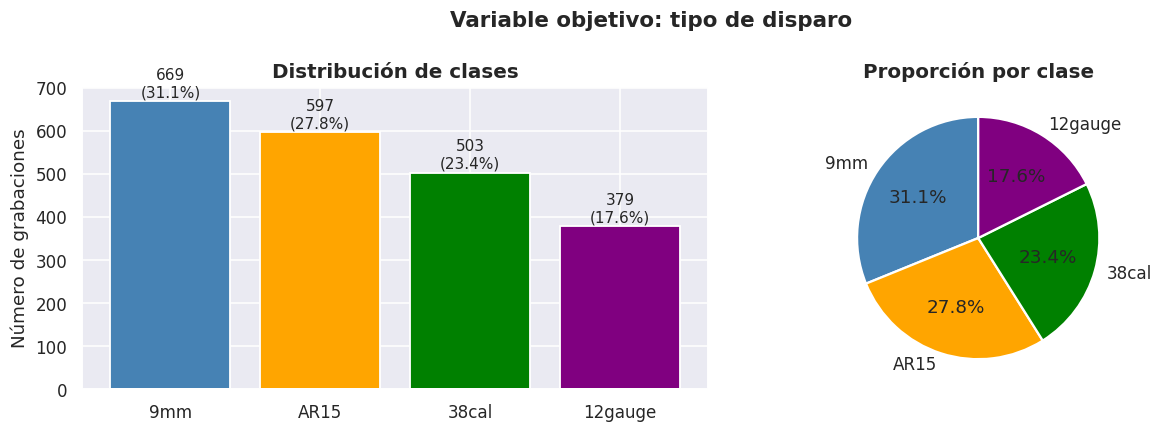

In [18]:
label_counts = df['label'].value_counts()
label_pct = (label_counts / len(df) * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barras
colors = ['steelblue','orange','green','purple']
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title("Distribución de clases")
axes[0].set_ylabel("Número de grabaciones")
for i, (v, p) in enumerate(zip(label_counts.values, label_pct.values)):
    axes[0].text(i, v + 10, f"{v}\n({p}%)", ha='center', fontsize=10)

# Pie
axes[1].pie(label_counts.values, labels=label_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title("Proporción por clase")

plt.suptitle("Variable objetivo: tipo de disparo", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
print("\nConteo por clase:")
display(pd.DataFrame({'Grabaciones': label_counts, '%': label_pct}))


Conteo por clase:


,Grabaciones,%
label,,
9mm,669,31.1
AR15,597,27.8
38cal,503,23.4
12gauge,379,17.6


## **4. Dispositivos de grabación**

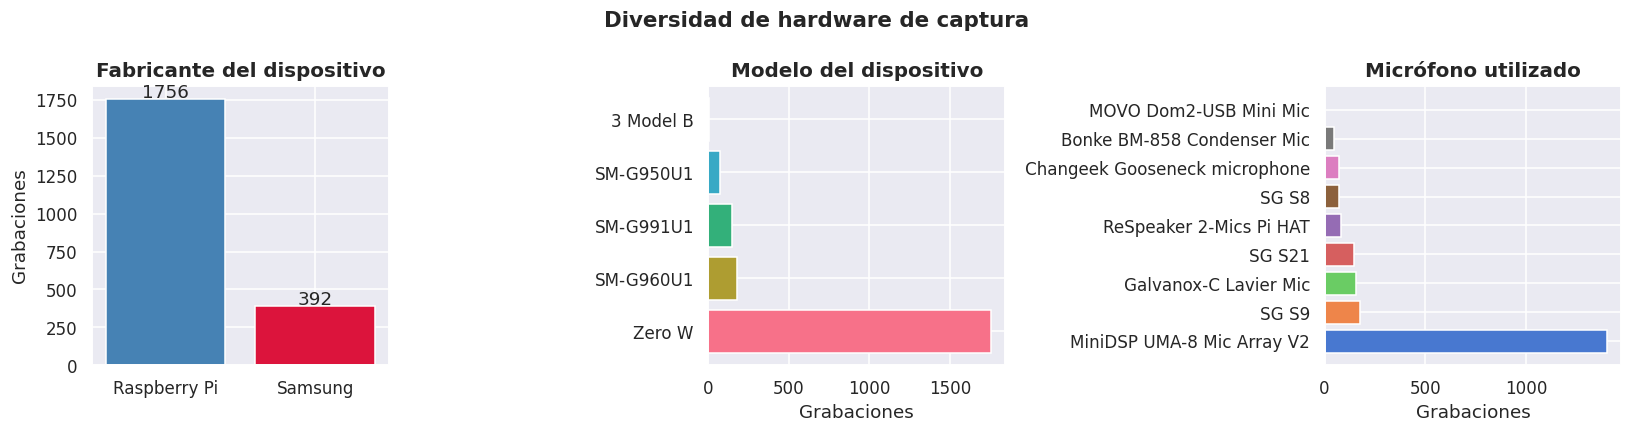

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Fabricante
mfr = df['device_manufacturer'].value_counts()
axes[0].bar(mfr.index, mfr.values, color=['steelblue','crimson'], edgecolor='white')
axes[0].set_title("Fabricante del dispositivo")
axes[0].set_ylabel("Grabaciones")
for i, v in enumerate(mfr.values):
    axes[0].text(i, v + 10, str(v), ha='center')

# Modelo
model = df['device_model'].value_counts()
axes[1].barh(model.index, model.values, color=sns.color_palette("husl", len(model)))
axes[1].set_title("Modelo del dispositivo")
axes[1].set_xlabel("Grabaciones")

# Micrófono
mic = df['microphone'].value_counts()
mic_short = mic.copy()
mic_short.index = [m.replace("Samsung Galaxy ","SG ").replace(" Internal Mic","").replace(" USB","") for m in mic.index]
axes[2].barh(mic_short.index, mic_short.values, color=sns.color_palette("muted", len(mic_short)))
axes[2].set_title("Micrófono utilizado")
axes[2].set_xlabel("Grabaciones")

plt.suptitle("Diversidad de hardware de captura", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

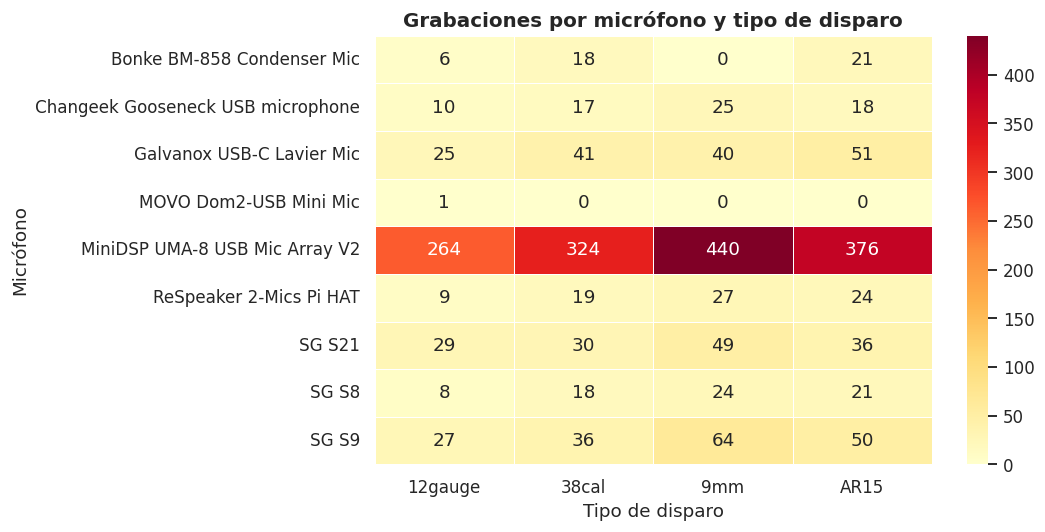

Los micrófonos internos de Samsung dominan; conviene verificar si el modelo no se aprende el hardware en lugar del disparo.


In [21]:
# Heatmap: micrófono vs. clase
hm = pd.crosstab(df['microphone'].str.replace("Samsung Galaxy ","SG ").str.replace(" Internal Mic",""), df['label'])
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(hm, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title("Grabaciones por micrófono y tipo de disparo")
ax.set_xlabel("Tipo de disparo")
ax.set_ylabel("Micrófono")
plt.tight_layout()
plt.show()
print("Los micrófonos internos de Samsung dominan; conviene verificar si el modelo no se aprende el hardware en lugar del disparo.")

## **5. Análisis de armas y calibres**

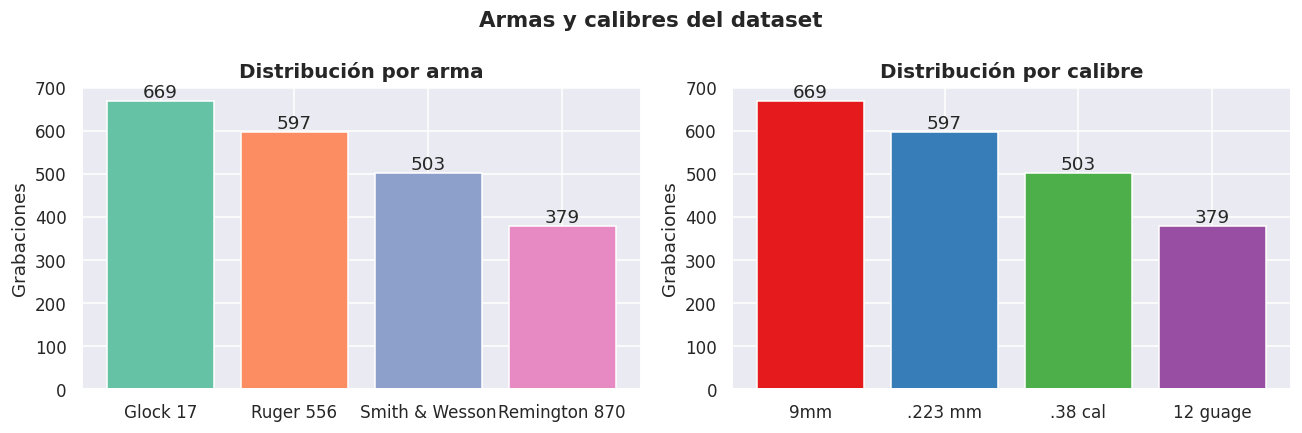

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

firearm = df['firearm'].value_counts()
caliber = df['caliber'].value_counts()

axes[0].bar(firearm.index, firearm.values, color=sns.color_palette("Set2", len(firearm)), edgecolor='white')
axes[0].set_title("Distribución por arma")
axes[0].set_ylabel("Grabaciones")
for i, v in enumerate(firearm.values):
    axes[0].text(i, v + 8, str(v), ha='center')

axes[1].bar(caliber.index, caliber.values, color=sns.color_palette("Set1", len(caliber)), edgecolor='white')
axes[1].set_title("Distribución por calibre")
axes[1].set_ylabel("Grabaciones")
for i, v in enumerate(caliber.values):
    axes[1].text(i, v + 8, str(v), ha='center')

plt.suptitle("Armas y calibres del dataset", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **6. Número de disparos por grabación**

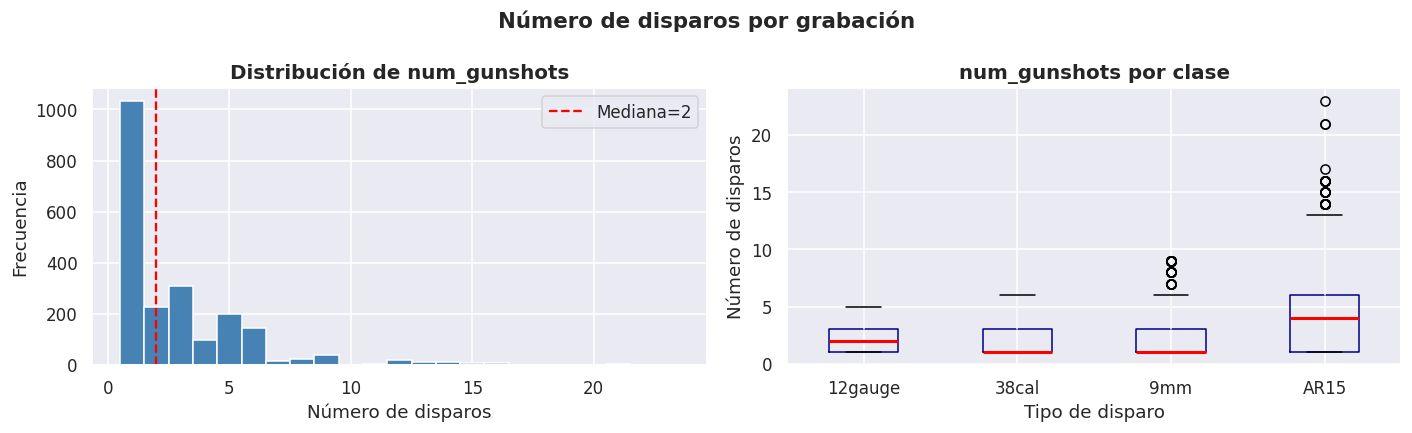

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma general
axes[0].hist(df['num_gunshots'], bins=range(1, df['num_gunshots'].max()+2),
             color='steelblue', edgecolor='white', align='left')
axes[0].set_title("Distribución de num_gunshots")
axes[0].set_xlabel("Número de disparos")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(df['num_gunshots'].median(), color='red', linestyle='--', label=f"Mediana={df['num_gunshots'].median():.0f}")
axes[0].legend()

# Boxplot por clase
df.boxplot(column='num_gunshots', by='label', ax=axes[1],
           boxprops=dict(color='darkblue'), medianprops=dict(color='red', linewidth=2))
axes[1].set_title("num_gunshots por clase")
axes[1].set_xlabel("Tipo de disparo")
axes[1].set_ylabel("Número de disparos")
plt.suptitle("")

plt.suptitle("Número de disparos por grabación", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
print(df.groupby('label')['num_gunshots'].describe().round(2))

         count  mean   std  min  25%  50%  75%   max
label                                               
12gauge  379.0  2.38  1.39  1.0  1.0  2.0  3.0   5.0
38cal    503.0  2.15  1.84  1.0  1.0  1.0  3.0   6.0
9mm      669.0  2.12  1.88  1.0  1.0  1.0  3.0   9.0
AR15     597.0  4.71  3.96  1.0  1.0  4.0  6.0  23.0


## **7. Sesiones de grabación**

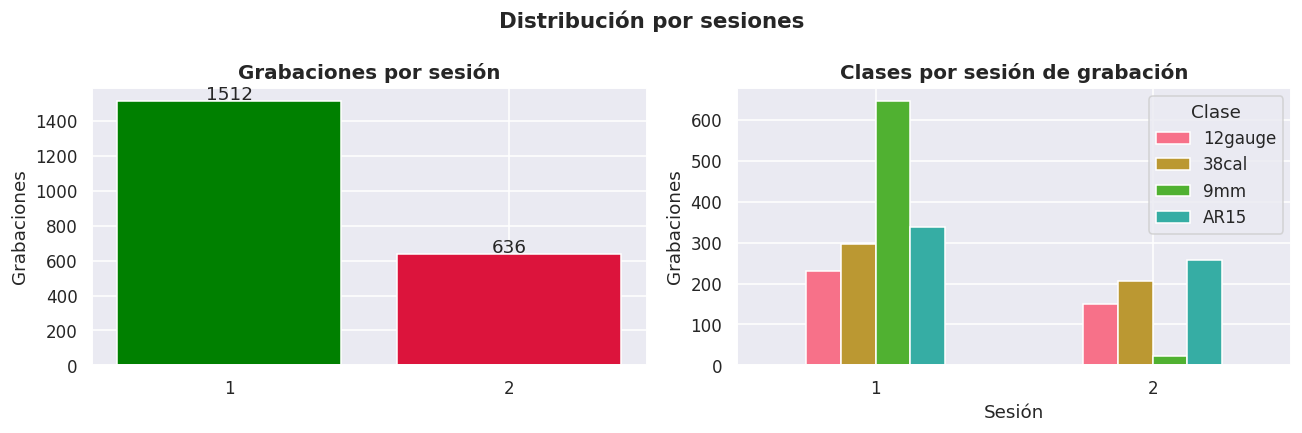

In [25]:
session = df['recording_session'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(session.index.astype(str), session.values, color=['green','crimson'], edgecolor='white')
axes[0].set_title("Grabaciones por sesión")
axes[0].set_ylabel("Grabaciones")
for i, v in enumerate(session.values):
    axes[0].text(i, v + 10, str(v), ha='center')

# Sesión × clase
sess_label = pd.crosstab(df['recording_session'], df['label'])
sess_label.plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title("Clases por sesión de grabación")
axes[1].set_xlabel("Sesión")
axes[1].set_ylabel("Grabaciones")
axes[1].legend(title='Clase')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle("Distribución por sesiones", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **8. Análisis temporal**

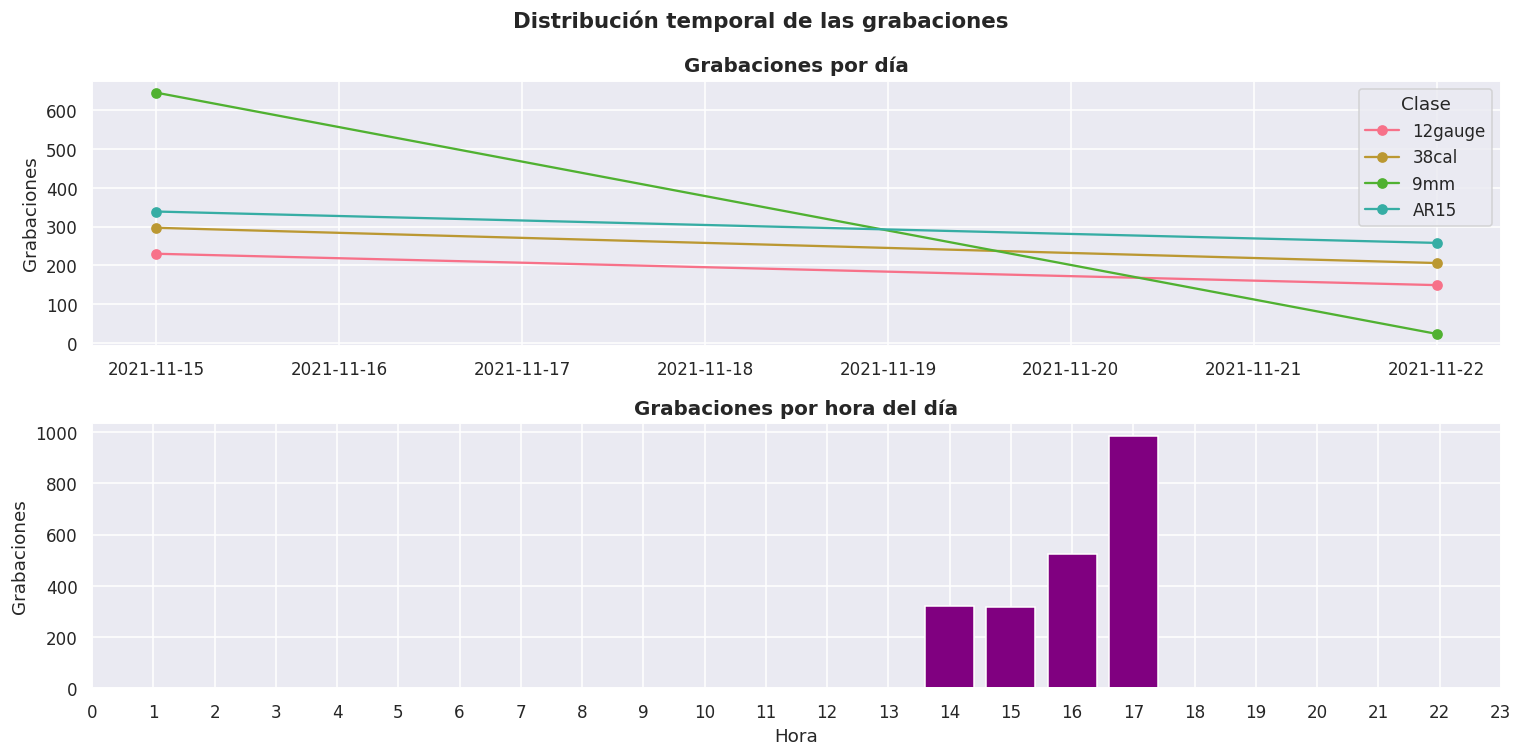

In [26]:
df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Por fecha
daily = df.groupby(['date','label']).size().unstack(fill_value=0)
daily.plot(ax=axes[0], marker='o', linewidth=1.5)
axes[0].set_title("Grabaciones por día")
axes[0].set_ylabel("Grabaciones")
axes[0].set_xlabel("")
axes[0].legend(title='Clase')

# Por hora
hourly = df.groupby('hour')['uuid'].count()
axes[1].bar(hourly.index, hourly.values, color='purple', edgecolor='white')
axes[1].set_title("Grabaciones por hora del día")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("Grabaciones")
axes[1].set_xticks(range(0, 24))

plt.suptitle("Distribución temporal de las grabaciones", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **9. Distribución geográfica**

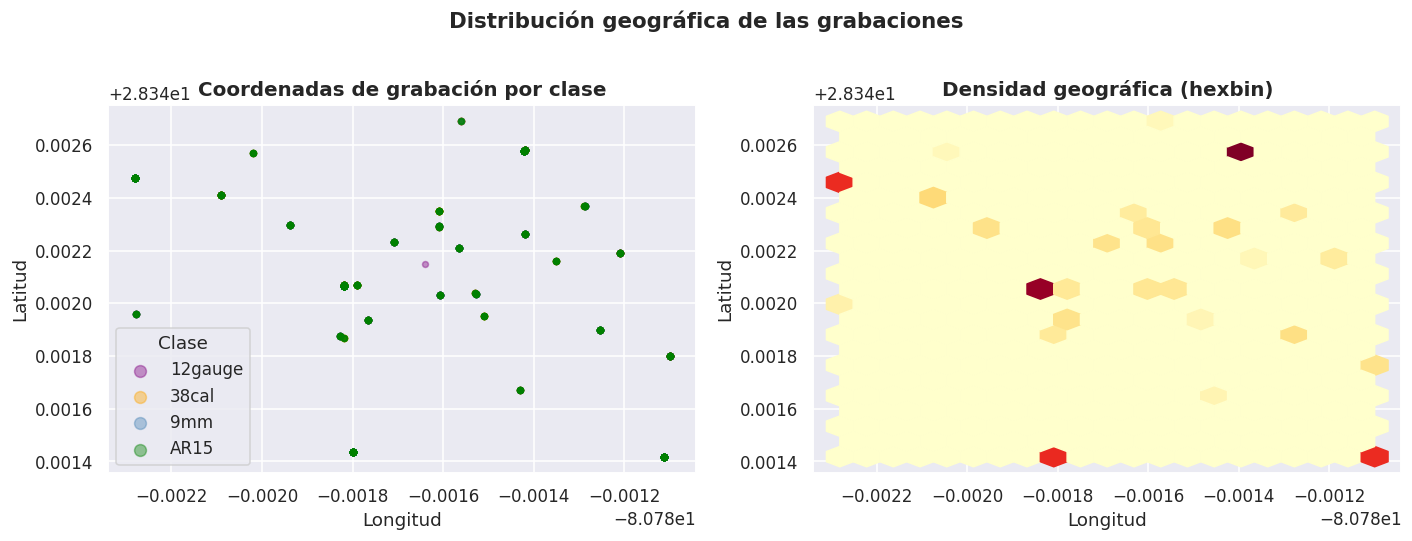

Todas las grabaciones provienen de una sola área (~1 campo de tiro). El modelo NO aprenderá geolocalización generalizable.


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_map = {'9mm':'steelblue','38cal':'orange','AR15':'green','12gauge':'purple'}

for label, grp in df.groupby('label'):
    axes[0].scatter(grp['longitude'], grp['latitude'], label=label,
                    alpha=0.4, s=15, color=colors_map.get(label, 'gray'))
axes[0].set_title("Coordenadas de grabación por clase")
axes[0].set_xlabel("Longitud")
axes[0].set_ylabel("Latitud")
axes[0].legend(title='Clase', markerscale=2)

# Zoom densidad
axes[1].hexbin(df['longitude'], df['latitude'], gridsize=20, cmap='YlOrRd')
axes[1].set_title("Densidad geográfica (hexbin)")
axes[1].set_xlabel("Longitud")
axes[1].set_ylabel("Latitud")

plt.suptitle("Distribución geográfica de las grabaciones", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Todas las grabaciones provienen de una sola área (~1 campo de tiro). El modelo NO aprenderá geolocalización generalizable.")

## **10. Desfase temporal (`time_offset_s`)**

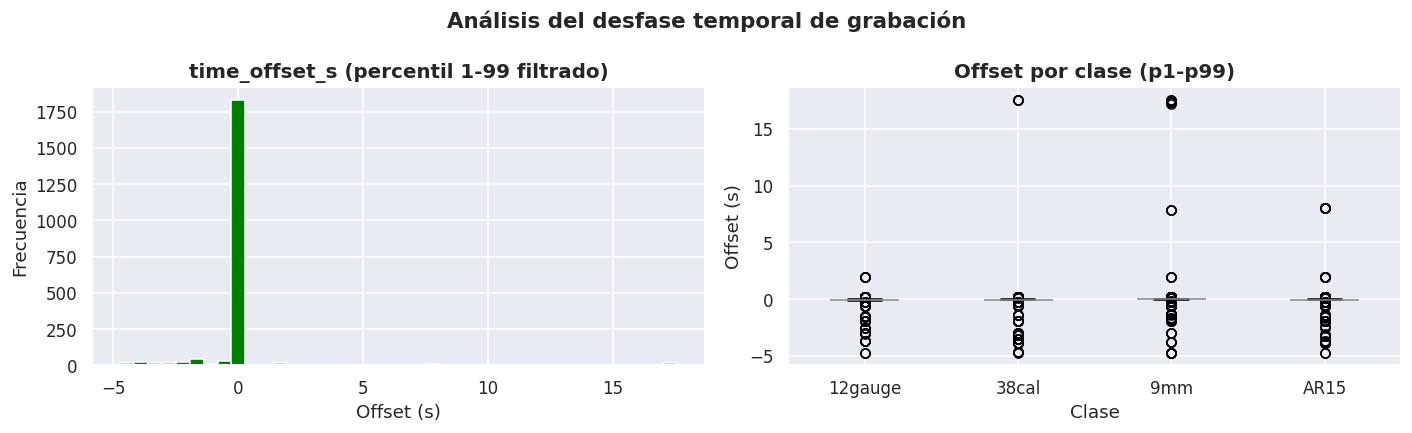

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución (sin outliers extremos)
valid = df['time_offset_clean'].dropna()
axes[0].hist(valid, bins=40, color='green', edgecolor='white')
axes[0].set_title("time_offset_s (percentil 1-99 filtrado)")
axes[0].set_xlabel("Offset (s)")
axes[0].set_ylabel("Frecuencia")

# Boxplot por clase
df.boxplot(column='time_offset_clean', by='label', ax=axes[1])
axes[1].set_title("Offset por clase (p1-p99)")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Offset (s)")
plt.suptitle("")

plt.suptitle("Análisis del desfase temporal de grabación", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
print("Estadísticas de time_offset_clean:")
df.groupby('label')['time_offset_clean'].describe().round(4)

Estadísticas de time_offset_clean:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
12gauge,361.0,-0.1656,0.7358,-4.705,-0.0593,-0.0322,-0.0029,1.953
38cal,483.0,-0.1886,1.6619,-4.714,-0.0617,-0.0495,-0.0191,17.559
9mm,631.0,0.3176,2.8028,-4.722,-0.0580,-0.0274,0.0051,17.579
AR15,573.0,-0.0976,1.1914,-4.721,-0.0588,-0.0498,-0.0139,8.054


## **11. Correlaciones entre variables numéricas**

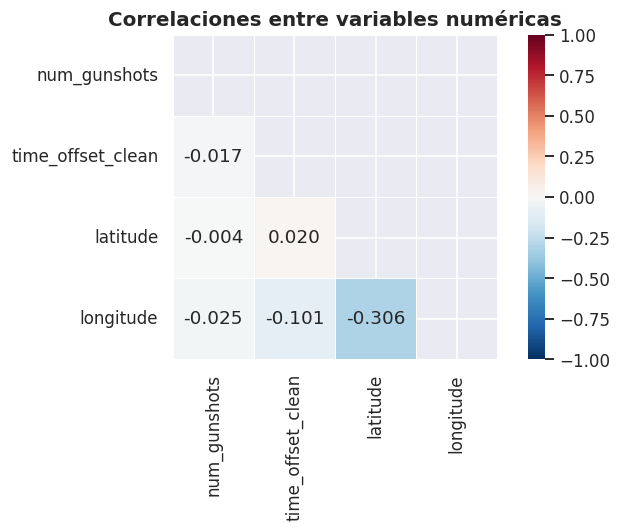

In [30]:
num_cols = ['num_gunshots', 'time_offset_clean', 'latitude', 'longitude']
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', vmin=-1, vmax=1,
            mask=mask, square=True, linewidths=0.5, ax=ax)
ax.set_title("Correlaciones entre variables numéricas")
plt.tight_layout()
plt.show()

## **12. Resumen y consideraciones para el modelo**

| Dimensión | Hallazgo | Recomendación |
|---|---|---|
| **Balance de clases** | Distribución desigual (~40 % = 9mm) | Aplicar `class_weight` o aplicar oversampling. |
| **Nulos** | 2.7 % en `time_offset_s` | Imputar con mediana por clase. |
| **Outliers offset** | Valores de >10⁶ s (probablemente epoch UNIX) | Normalizar o excluir en el preprocesamiento. |
| **Hardware** | 2 fabricantes, 9 micrófonos distintos | Auditar si el modelo sobreajusta al micrófono. |
| **Geografía** | Todas las grabaciones en ~1 campo de tiro | El sistema de alertas deberá generalizarse a otros entornos. |
| **Disparos múltiples** | Mediana 2, máximo 23 | Segmentar audio por `gunshot_location_in_seconds`. |
| **Temporal** | Datos de 2 sesiones (noviembre de 2021) | Dataset pequeño; consideremos data augmentation de audio. |

### **Próximos pasos**
1. **Feature engineering de audio**: extraer MFCCs, espectrogramas mel y zero-crossing rate a partir del campo `filename`.
2. **Segmentación**: usar `gunshot_location_in_seconds` para aislar ventanas de disparo.
3. **Balanceo**: evaluar SMOTE en el espacio de features o augmentation de audio.
4. **Baseline**: entrenar un clasificador simple (Random Forest sobre features estadísticas de audio) antes de pasar a deep learning.
5. **Validación cruzada**: separar por `recording_session` para evitar data leakage entre sesiones.